In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from numpy import linspace
from scipy.stats import gaussian_kde

import statsmodels.api as sm
import statsmodels.formula.api as smf

pd.set_option("future.no_silent_downcasting", True)

### Exploratory Data Analysis

**Visualizing Distributions**

In [3]:
oscars_summary = pd.read_csv("oscars_summary.csv")
acting_summary = pd.read_csv("acting_summary.csv")
gender_age = pd.read_csv("gender_age.csv")
gender_rt = pd.read_csv("gender_rt.csv")

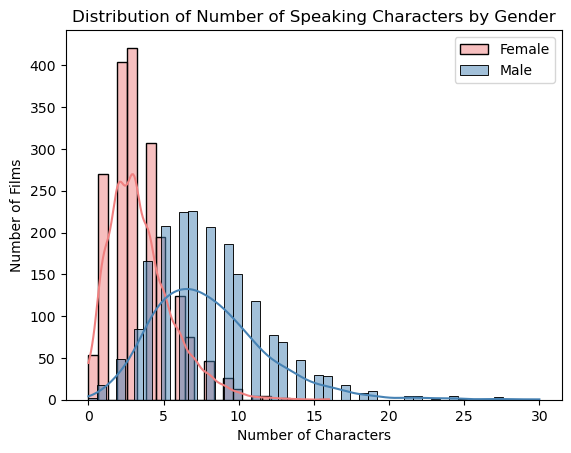

In [4]:
sns.histplot(
    data=oscars_summary, 
    x="num_characters_f", 
    color="lightcoral", 
    label="Female", 
    bins=25,
    kde=True
)
sns.histplot(
    data=oscars_summary, 
    x="num_characters_m", 
    color="steelblue", 
    label="Male", 
    bins=50,
    kde=True)

plt.title("Distribution of Number of Speaking Characters by Gender")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Films")
plt.legend() 
plt.show()

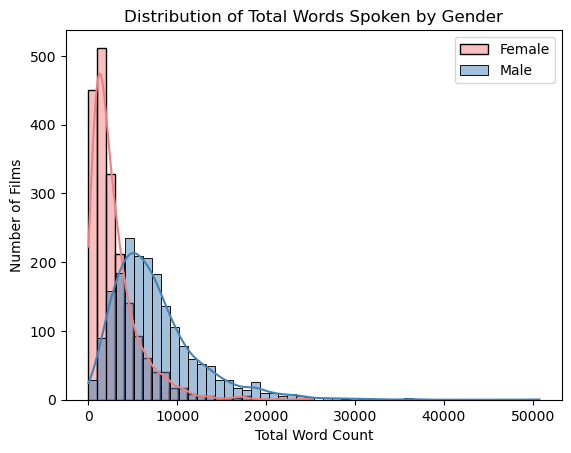

In [5]:
sns.histplot(
    data=oscars_summary, 
    x="total_words_f", 
    color="lightcoral", 
    label="Female", 
    bins=25,
    kde=True
)
sns.histplot(
    data=oscars_summary, 
    x="total_words_m", 
    color="steelblue", 
    label="Male", 
    bins=50,
    kde=True)

plt.title("Distribution of Total Words Spoken by Gender")
plt.xlabel("Total Word Count")
plt.ylabel("Number of Films")
plt.legend() 
plt.show()

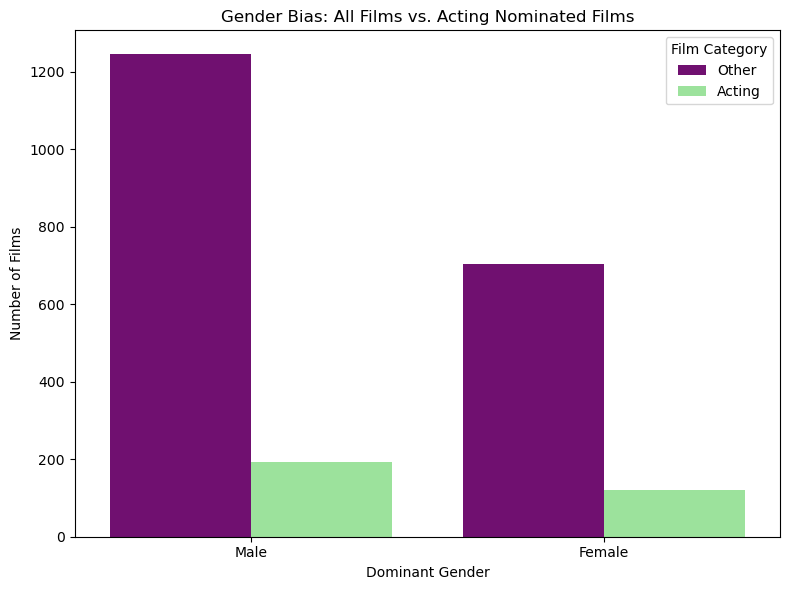

In [6]:
combined = pd.concat([oscars_summary, acting_summary], ignore_index=True)

plt.figure(figsize=(8, 6))
sns.countplot(
    data=combined,
    x="dominant_gender",
    hue="df_type",
    order=["m", "f"],
    palette={"Other": "purple", "Acting": "lightgreen"}
)

plt.title("Gender Bias: All Films vs. Acting Nominated Films")
plt.xlabel("Dominant Gender")
plt.ylabel("Number of Films")
plt.xticks([0, 1], ["Male", "Female"])
plt.legend(title="Film Category")
plt.tight_layout()
plt.show()


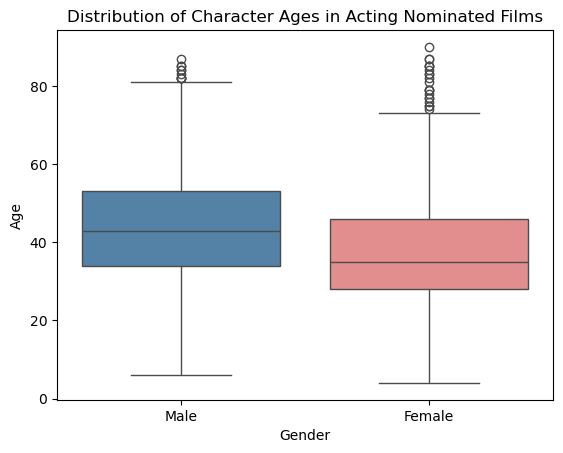

In [7]:
sns.boxplot(
    data=gender_age, 
    x="gender", 
    y="age",
    palette={"m": "steelblue", "f": "lightcoral"},
    order=["m", "f"],
    hue="gender"
)

plt.title("Distribution of Character Ages in Acting Nominated Films")
plt.xlabel("Gender")
plt.ylabel("Age")
plt.xticks([0, 1], ["Male", "Female"])
plt.show()

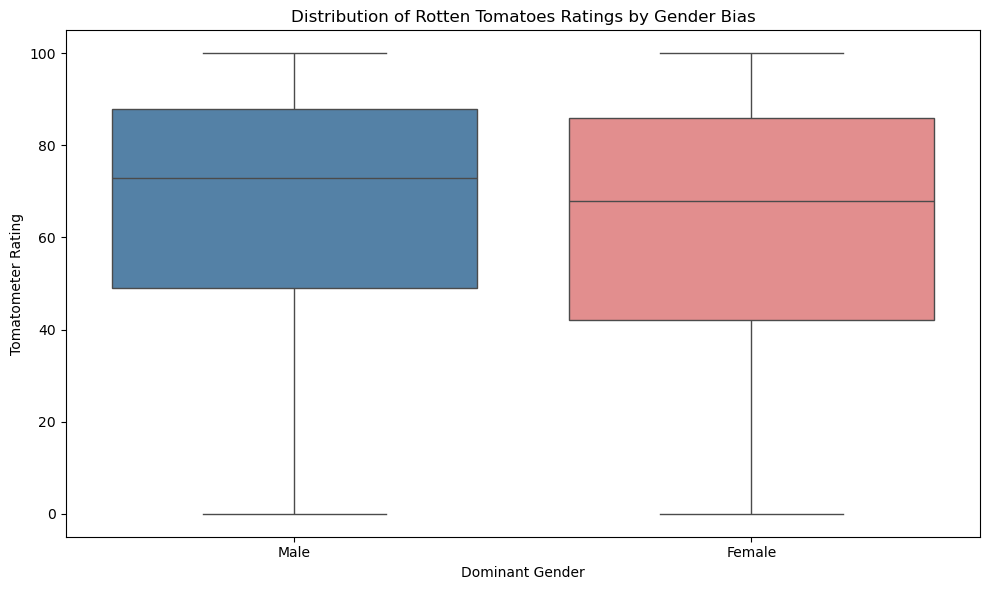

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=gender_rt,
    x="dominant_gender",
    y="tomatometer_rating",
    palette={"m": "steelblue", "f": "lightcoral"},
    order=["m", "f"],
    hue="dominant_gender"
)

plt.title("Distribution of Rotten Tomatoes Ratings by Gender Bias")
plt.xlabel("Dominant Gender")
plt.xticks([0, 1], ["Male", "Female"])
plt.ylabel("Tomatometer Rating")
plt.tight_layout()
plt.show()

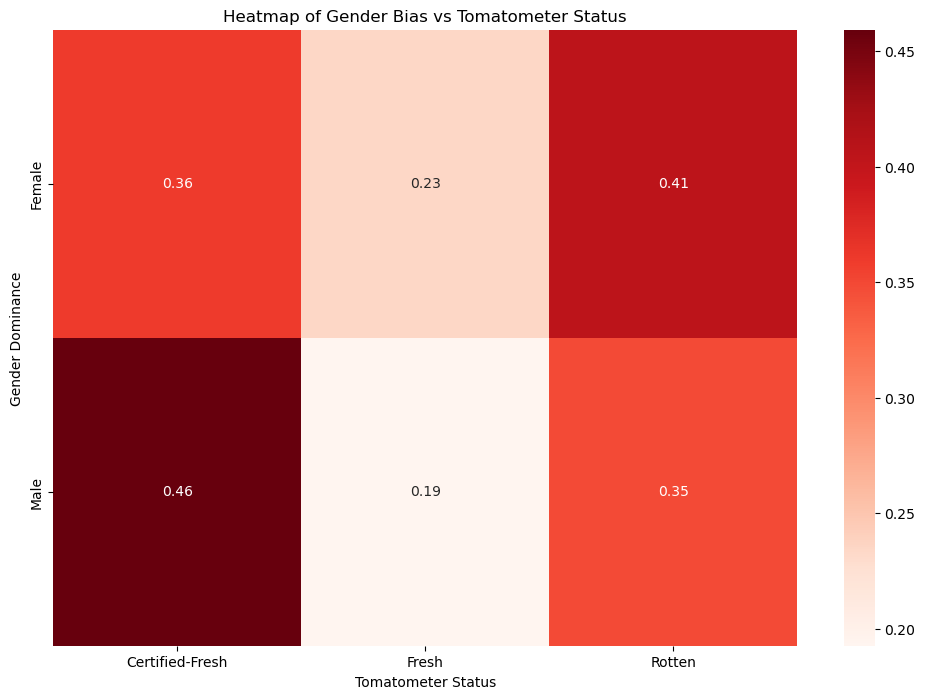

In [ ]:
ct_rt = pd.crosstab(gender_rt["dominant_gender"], gender_rt["tomatometer_status"])
ct_rt_scaled = ct_rt.div(ct_rt.sum(axis=1), axis=0)

sns.heatmap(
    ct_rt_scaled,
    annot=True,
    cmap="Reds",
)

plt.title("Heatmap of Gender Bias vs Tomatometer Status")
plt.xlabel("Tomatometer Status")
plt.ylabel("Gender Dominance")
plt.yticks(ticks=[0.5, 1.5], labels=["Female", "Male"])
plt.show()